In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torchaudio

from soundbay.utils.metadata_processing import get_wav_info_df, add_month_acc_duration, load_annotation_correct_file_time, get_dir_wav_info, load_dir_annotation_with_file_time

# load input Dataframe

In [ ]:
DATASET_PATH = Path("datasets/fannie_project")
train_df = pd.read_csv(DATASET_PATH / "train_updated.csv")
train_df.head()

,filename,begin_time,end_time,low_freq,high_freq,label,call_length
0,5756.210602,251.371428,258.149664,23.750,26.179,1,6.778237
1,5756.220413,545.393381,552.673709,23.663,26.169,1,7.280328
2,5756.210728,133.702498,140.480735,23.752,26.200,1,6.778237
3,5756.210527,346.054302,352.204924,23.773,26.212,1,6.150622
4,5756.210515,97.889953,103.412961,23.754,26.240,1,5.523008


In [4]:
train_df.shape

(15532, 7)

In [5]:
# check for duplications in train_df
duplicate_rows = train_df[train_df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
# remove duplicates
train_df = train_df.drop_duplicates()
print(f"Shape of train_df after removing duplicates: {train_df.shape}")

Number of duplicate rows: 152
Shape of train_df after removing duplicates: (15380, 7)


In [20]:
# find overlaps between annotations in train_df
def find_max_overlaps(df, time_segment=1.0, hop_time=0.25, noise_label=0):
    max_overlaps = 0
    overlap_dict = {}
    files = df['filename'].unique()
    m_df = df[df['label'] != noise_label]
    for filename in tqdm(files):
        file_df = m_df[m_df['filename'] == filename]
        for _, row in file_df.iterrows():
            start_time = row['begin_time']
            end_time = row['end_time']
            # Create time segments
            segments = np.arange(start_time, end_time, hop_time)
            for segment_start in segments:
                segment_end = segment_start + time_segment
                # Count overlaps in this segment
                overlaps = file_df[(file_df['begin_time'] < segment_end) & (file_df['end_time'] > segment_start)].shape[0]

                if overlaps in overlap_dict:
                    overlap_dict[overlaps] += 1
                else:                    
                    overlap_dict[overlaps] = 1
                # max_overlaps = max(max_overlaps, overlaps)
    return overlap_dict

overlap_dict = find_max_overlaps(train_df, time_segment=5.0, hop_time=0.25, noise_label=0)
print(f"Maximum number of overlapping annotations: {max(overlap_dict.keys())}")
print(f"Overlap distribution: {overlap_dict}")

100%|██████████| 3675/3675 [00:56<00:00, 64.97it/s] 

Maximum number of overlapping annotations: 4
Overlap distribution: {1: 443451, 2: 10889, 3: 914, 4: 54}


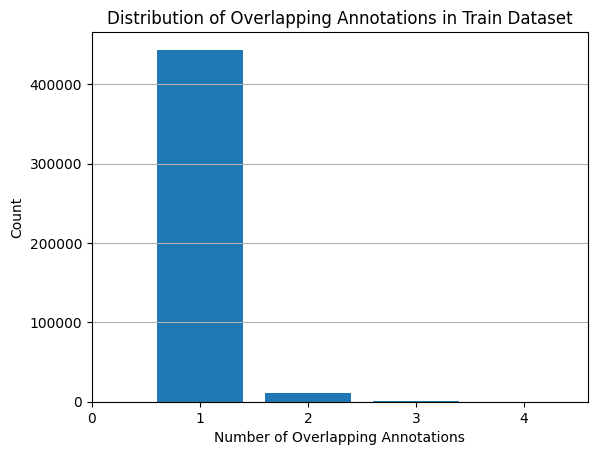

In [21]:
import matplotlib.pyplot as plt
plt.bar(overlap_dict.keys(), overlap_dict.values())
plt.xlabel('Number of Overlapping Annotations')
plt.ylabel('Count')
plt.title('Distribution of Overlapping Annotations in Train Dataset')
plt.xticks(range(0, max(overlap_dict.keys()) + 1))
plt.grid(axis='y')
plt.show()

# Develop dataloader

In [6]:
import torch

In [7]:
n_overlaps = 4
xs = np.random.rand(n_overlaps)
ys = np.random.rand(n_overlaps)
ws = np.random.rand(n_overlaps)
hs = np.random.rand(n_overlaps)
classes = np.random.randint(0, 10, n_overlaps)
confidences = np.random.rand(n_overlaps)

In [8]:
tens = torch.tensor([xs, ys, ws, hs, classes, confidences]).T
print(tens.shape)
tens

torch.Size([4, 6])


/tmp/ipykernel_26154/246380178.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  tens = torch.tensor([xs, ys, ws, hs, classes, confidences]).T


tensor([[0.6976, 0.8033, 0.5061, 0.6036, 6.0000, 0.5796],
        [0.9394, 0.5903, 0.1128, 0.8183, 9.0000, 0.2829],
        [0.7692, 0.2776, 0.1879, 0.4099, 6.0000, 0.1520],
        [0.4241, 0.7896, 0.7191, 0.4783, 7.0000, 0.3630]], dtype=torch.float64)

In [9]:
len(train_df['filename'].unique())

3675

find the times from file df that need segment. it can be thought as bracket problem:

(---(-)----)------(------)------(---)-(-------)--(--(--)--)--

need to be:

(----------)------(------)------(-------------)--(--------)--


In [39]:
def find_annotated_segments(file_df: pd.DataFrame, shpil_sec: float = 1.0):
    sorted_df = file_df.sort_values(by='begin_time')
    segments = []
    current_segment_start = sorted_df.iloc[0]['begin_time']
    current_segment_end = sorted_df.iloc[0]['end_time']
    for _, row in sorted_df.iterrows():
        if row['begin_time'] <= current_segment_end + shpil_sec:
            current_segment_end = max(current_segment_end, row['end_time'])
        else:
            segments.append((current_segment_start, current_segment_end)) # TODO: add metadata needed
            current_segment_start = row['begin_time']
            current_segment_end = row['end_time']
    segments.append((current_segment_start, current_segment_end))
    return segments

def cut_segment_into_chunks(segment_start: float, segment_end: float, chunk_size: float = 1.0, hop_size: float = 0.5) -> pd.DataFrame:
    chunks = []
    current_start = segment_start
    while current_start + chunk_size <= segment_end:
        current_end = current_start + chunk_size
        chunks.append((current_start, current_end))
        current_start += hop_size
    
    if current_start < segment_end:
        chunks.append((segment_end - chunk_size, segment_end))

    return pd.DataFrame(chunks, columns=['begin_time', 'end_time'])

def find_annotations_in_segment(file_df: pd.DataFrame, segment_start: float, segment_end: float):
    return file_df[(file_df['begin_time'] < segment_end) & (file_df['end_time'] > segment_start)]

In [32]:
files = train_df.filename.unique()
print(len(files))
idx = 1

file_df = train_df[train_df['filename'] == files[idx]]
print(len(file_df))
segments = find_annotated_segments(file_df, shpil_sec=2.0)
print(f"Annotated segments for file {files[idx]}: {len(segments)}")

3675
12
Annotated segments for file 5756.220413063455: 11


In [35]:
file_df.sort_values(by='begin_time')

,filename,begin_time,end_time,low_freq,high_freq,label,call_length
6182,5756.220413,110.100008,124.535142,31.459,34.345,2,14.435134
1291,5756.220413,110.255308,119.292957,23.941,26.169,1,9.037649
9146,5756.220413,215.589550,233.915894,31.459,34.345,2,18.326344
5617,5756.220413,274.008003,287.313431,31.170,34.345,2,13.305428
7640,5756.220413,342.743939,355.923843,31.459,34.345,2,13.179905
8971,5756.220413,358.559824,367.974042,31.170,34.345,2,9.414218
225,5756.220413,406.338921,413.995818,23.941,26.169,1,7.656897
1,5756.220413,545.393381,552.673709,23.663,26.169,1,7.280328
7572,5756.220413,646.283705,662.225114,31.459,34.345,2,15.941409
5434,5756.220413,693.781666,706.459479,31.170,34.345,2,12.677813


In [38]:
file_df = train_df[train_df['filename'] == files[idx]]
print(len(file_df))
segments = find_annotated_segments(file_df, shpil_sec=2.0)
print(f"Annotated segments for file {files[idx]}: {len(segments)}")
for segment_start, segment_end in segments:
    annotations_in_segment = find_annotations_in_segment(file_df, segment_start, segment_end)
    print(f"Segment {segment_start:.2f} - {segment_end:.2f} has {len(annotations_in_segment)} annotations")

12
Annotated segments for file 5756.220413063455: 11
Segment 110.10 - 124.54 has 2 annotations
Segment 215.59 - 233.92 has 1 annotations
Segment 274.01 - 287.31 has 1 annotations
Segment 342.74 - 355.92 has 1 annotations
Segment 358.56 - 367.97 has 1 annotations
Segment 406.34 - 414.00 has 1 annotations
Segment 545.39 - 552.67 has 1 annotations
Segment 646.28 - 662.23 has 1 annotations
Segment 693.78 - 706.46 has 1 annotations
Segment 803.54 - 813.83 has 1 annotations
Segment 818.76 - 827.29 has 1 annotations


In [45]:
file_df = train_df[train_df['filename'] == files[idx]]
segments = find_annotated_segments(file_df, shpil_sec=2.0)

chunks = []
for segment_start, segment_end in segments:
    chunk_df = cut_segment_into_chunks(segment_start, segment_end, chunk_size=5.0, hop_size=2.0)
    chunk_df['filename'] = files[idx]
    chunks.append(chunk_df)
chunks_df = pd.concat(chunks, ignore_index=True)
chunks_df.head()

,begin_time,end_time,filename
0,110.100008,115.100008,5756.220413
1,112.100008,117.100008,5756.220413
2,114.100008,119.100008,5756.220413
3,116.100008,121.100008,5756.220413
4,118.100008,123.100008,5756.220413


In [49]:
find_annotations_in_segment(file_df, chunks_df.iloc[0]['begin_time'], chunks_df.iloc[0]['end_time'])

,filename,begin_time,end_time,low_freq,high_freq,label,call_length
1291,5756.220413,110.255308,119.292957,23.941,26.169,1,9.037649
6182,5756.220413,110.100008,124.535142,31.459,34.345,2,14.435134


In [57]:
chunks_df["n_annotations"] = chunks_df.apply(lambda row: find_annotations_in_segment(file_df, row['begin_time'], row['end_time']).shape[0], axis=1)
chunks_df.head()

,begin_time,end_time,filename,n_annotations
0,110.100008,115.100008,5756.220413,2
1,112.100008,117.100008,5756.220413,2
2,114.100008,119.100008,5756.220413,2
3,116.100008,121.100008,5756.220413,2
4,118.100008,123.100008,5756.220413,2


In [141]:
##### ORIGINAL
def get_label(segments_df: pd.DataFrame, metadata_df: pd.DataFrame, idx: int, wanted_sample_rate = 16000, max_overlap_labels=4):
    file_name = segments_df['filename'][idx]
    segment_start = segments_df['begin_time'][idx]
    segment_end = segments_df['end_time'][idx]

    file_df = metadata_df[metadata_df['filename'] == file_name]
    annotations_in_segment = find_annotations_in_segment(file_df, segment_start, segment_end)

    annotations_in_segment = annotations_in_segment.sort_values(by='begin_time').head(max_overlap_labels)
    segment_length = segment_end - segment_start
    labels = torch.zeros((max_overlap_labels, 6), dtype=torch.float)
    for i, (_, row) in enumerate(annotations_in_segment.iterrows()):
        x = max(0, row['begin_time'] - segment_start) / segment_length
        y = max(0, row['low_freq'])
        w = min(segment_end, row['end_time']) - max(segment_start, row['begin_time'])
        w = w / segment_length
        h = (row['high_freq'] - row['low_freq'])
        cls = row['label']
        conf = 1.0
        labels[i] = torch.tensor([x, y, w, h, cls, conf], dtype=torch.float)

    return labels

In [ ]:
def get_audio(segments_df: pd.DataFrame, idx: int, dataset_path: Path, sample_rate = 16000):
    file_name = segments_df['filename'][idx]
    segment_start = segments_df['begin_time'][idx]
    segment_end = segments_df['end_time'][idx]

    audio, _ = torchaudio.load(dataset_path / (str(file_name) + '.wav'), 
                                frame_offset=int(segment_start * sample_rate), 
                                num_frames=int((segment_end - segment_start) * sample_rate)
                                )
    return audio

In [ ]:
audio, sr = torchaudio.load((DATASET_PATH / (str(chunks_df.iloc[idx]['filename']) + '.wav')),
                            frame_offset=int(chunks_df.iloc[idx]['begin_time'] * 1000), 
                        num_frames=int((chunks_df.iloc[idx]['end_time'] - chunks_df.iloc[idx]['begin_time']) * 1000)
                        )
audio.shape, sr
# int(segment_start * sr)

(torch.Size([1, 5000]), 1000)

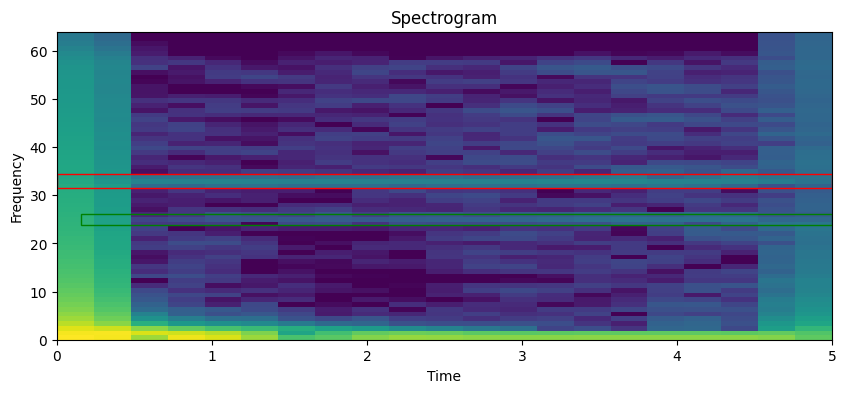

In [ ]:
idx = 0
audio = get_audio(chunks_df, idx, DATASET_PATH, sample_rate=1000).squeeze().numpy()
sr = 1000

target_sr = 128
resample_audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

plt.figure(figsize=(10, 4))

# plot the spectrogram
S = librosa.stft(resample_audio, n_fft=128, hop_length=32)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
plt.imshow(S_db, aspect='auto', origin='lower', extent=[0, chunks_df.iloc[idx]['end_time'] - chunks_df.iloc[idx]['begin_time'], 0, target_sr / 2])

# add rectangles for each annotation in the segment
label = get_label(chunks_df, train_df, idx)
x, y, w, h, cls, conf = label[0]
segment_length = chunks_df.iloc[idx]['end_time'] - chunks_df.iloc[idx]['begin_time']
rect = plt.Rectangle((x * segment_length, 
                      y), 
                      w * segment_length, 
                      h, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect)

x, y, w, h, cls, conf = label[1]
rect = plt.Rectangle((x * segment_length, 
                      y), 
                      w * segment_length, 
                      h, edgecolor='g', facecolor='none')
plt.gca().add_patch(rect)

plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()


tensor([[ 0.0000, 31.4590,  1.0000,  2.8860,  2.0000,  1.0000],
        [ 0.0000, 23.9410,  1.0000,  2.2280,  1.0000,  1.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]])


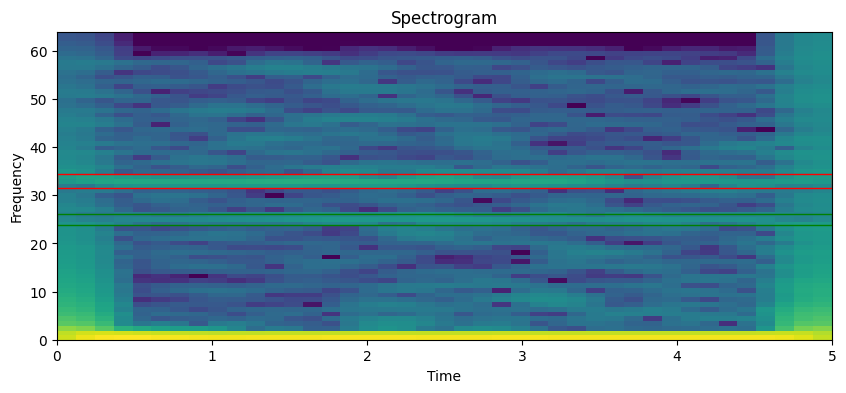

In [ ]:
# plot audio segment with annotations
idx = 1
audio = get_audio(chunks_df, idx, DATASET_PATH, sample_rate=1000).squeeze().numpy()
sr = 1000

target_sr = 128
resample_audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)

plt.figure(figsize=(10, 4))

# plot the spectrogram
S = librosa.stft(resample_audio, n_fft=128, hop_length=16)
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
plt.imshow(S_db, aspect='auto', origin='lower', extent=[0, chunks_df.iloc[idx]['end_time'] - chunks_df.iloc[idx]['begin_time'], 0, target_sr / 2])

# add rectangles for each annotation in the segment
label = get_label(chunks_df, train_df, idx)
print(label)
x, y, w, h, cls, conf = label[0]
segment_length = chunks_df.iloc[idx]['end_time'] - chunks_df.iloc[idx]['begin_time']
rect = plt.Rectangle((x * segment_length, 
                      y), 
                      w * segment_length, 
                      h, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect)

x, y, w, h, cls, conf = label[1]
rect = plt.Rectangle((x * segment_length, 
                      y), 
                      w * segment_length, 
                      h, edgecolor='g', facecolor='none')
plt.gca().add_patch(rect)

plt.title('Spectrogram')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()


### Develop augmentation